# Machine Learning models for Obesity Prediction



Machine learning frameworks for predicting Obesity from audio voice data


# Connect and authorize google drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ls

In [ ]:
%cd /content/gdrive/My Drive/Colab Notebooks/ML/sbi
!ls

In [ ]:
! pwd

# Install packages

In [ ]:
!pip install spectral_cube

# Libraries

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

import numpy as np
import pandas as pd
import scipy as sp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Audio
import librosa

from sklearn.decomposition import PCA

from astropy.io          import fits
from astropy             import units as u
from astropy.coordinates import SkyCoord
from astropy.wcs         import WCS

import h5py
import pickle


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn import svm


from pathlib import Path

# set seed for numpy and torch
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)


%matplotlib inline

In [ ]:
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'

# GPU or CPU

In [ ]:
# GPU or CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device: ', device)
print('device_count: ', torch.cuda.device_count())

print('Torch version: ', torch.__version__)
print('torch.version.cuda: ', torch.version.cuda)

print("Is CUDA enabled?",torch.cuda.is_available())

device:  cpu
device_count:  0
Torch version:  2.5.1+cu124
torch.version.cuda:  12.4
Is CUDA enabled? False


# Utils

In [ ]:
# Function to Plotting 10 features out of 20 of all features

def plot_features(frame, features):

    i = 0 # index of features
    j = 0 # for color

    color = ['r','g','b','y','c', 'k',
             'darkblue','lightgreen',
             'purple','orange','olive'
             ] # colors for plots

    # Number of rows
    nrows = 5

    # Creating Figure and Axis to plot
    fig, axes = plt.subplots(nrows, 2)

    # Setting Figure size
    fig.set_figheight(20)
    fig.set_figwidth(20)

    for row in axes:

        plot1 = frame[features[i]]
        plot2 = frame[features[i+1]]

        col = [color[j], color[j+1]]
        label = ['Voice feature: ' + features[i],
                 'Voice feature: ' + features[i+1]
                 ]

        plot(row, plot1,plot2,col,label)

        i += 4
        j += 2

    # plt.legend(fontsize=14)
    plt.show()



def plot(axrow, plot1, plot2, col, label):

    axrow[0].plot(plot1,label=label[0],color=col[0])

    axrow[0].set_xlabel('X', fontsize=16)
    axrow[0].set_ylabel('Y', fontsize=16)

    axrow[0].minorticks_on()
    axrow[0].tick_params(axis='x', labelsize=14, pad=4)
    axrow[0].tick_params(axis='y', labelsize=14)
    axrow[0].tick_params(which='both', width=2)
    axrow[0].tick_params(which='major', length=4)
    axrow[0].tick_params(which='minor', length=2)


    axrow[0].grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
    axrow[0].legend(loc='upper right', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=16.5)


    #
    axrow[1].plot(plot2,label=label[1],color=col[1])

    axrow[1].set_xlabel('X', fontsize=16)
    axrow[1].set_ylabel('Y', fontsize=16)

    axrow[1].minorticks_on()
    axrow[1].tick_params(axis='x', labelsize=14, pad=4)
    axrow[1].tick_params(axis='y', labelsize=14)
    axrow[1].tick_params(which='both', width=2)
    axrow[1].tick_params(which='major', length=4)
    axrow[1].tick_params(which='minor', length=2)


    axrow[1].grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
    axrow[1].legend(loc='upper right', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=16.5)

# Paths

In [ ]:
base_path = Path('/content/gdrive/MyDrive/Colab Notebooks/ML/')

sbi_path         = base_path / 'sbi'
checkpoint_path  = sbi_path / 'checkpoints'
data_path        = sbi_path / 'data'

# Read training dataset

In [ ]:
voice_data_file = data_path / 'voice_data.csv'
df = pd.read_csv(voice_data_file)
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,Yes
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,Yes
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,Yes
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,Yes
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,Yes


In [ ]:
print('Features: \n', df.keys())

Features: 
 Index(['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt',
       'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun',
       'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label'],
      dtype='object')


In [ ]:
# printing shape of Dataframe
nsamples, ncols =  df.shape
print('Shape of voice data frame:', nsamples, ncols)
print('Number of samples:', nsamples)
print('Number of columns:', ncols)

Shape of voice data frame: 3168 21
Number of samples: 3168
Number of columns: 21


In [ ]:
# Check for missing values
print('Missing Values')
print(df.isnull().sum())

Missing Values
meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64


In [ ]:
# GOOD! No missing data

# Obesity - Pie Chart

In [ ]:
df['label'].value_counts()[1]

<ipython-input-70-3bda6eb80bcf>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['label'].value_counts()[1]


1584

In [ ]:
# label for obesity
# 1: Yes
# 0: No
obesity_counts = df['label'].value_counts()
obesity_yes = obesity_counts[0]
obesity_no  = obesity_counts[1]
obesity_counts

<ipython-input-71-89cde3c79652>:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  obesity_yes = obesity_counts[0]
<ipython-input-71-89cde3c79652>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  obesity_no  = obesity_counts[1]


,count
label,
Yes,1584
No,1584


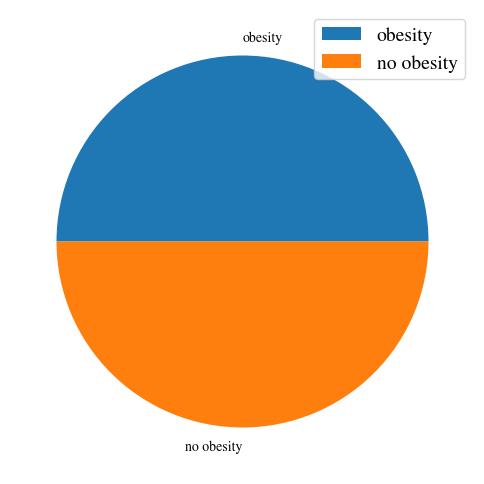

In [ ]:
val= [obesity_yes, obesity_no]
label = ['obesity','no obesity']
plt.figure(figsize=(6,8))
plt.pie(val,labels=label)
plt.legend(fontsize=14)
plt.show()

#  Correalation of Features

In [ ]:
# Finding Correalation of Features
df.drop(['label'], axis=1).corr()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
meanfreq,1.000000,-0.739039,0.925445,0.911416,0.740997,-0.627605,-0.322327,-0.316036,-0.601203,-0.784332,0.687715,1.000000,0.460844,0.383937,0.274004,0.536666,0.229261,0.519528,0.515570,-0.216979
sd,-0.739039,1.000000,-0.562603,-0.846931,-0.161076,0.874660,0.314597,0.346241,0.716620,0.838086,-0.529150,-0.739039,-0.466281,-0.345609,-0.129662,-0.482726,-0.357667,-0.482278,-0.475999,0.122660
median,0.925445,-0.562603,1.000000,0.774922,0.731849,-0.477352,-0.257407,-0.243382,-0.502005,-0.661690,0.677433,0.925445,0.414909,0.337602,0.251328,0.455943,0.191169,0.438919,0.435621,-0.213298
Q25,0.911416,-0.846931,0.774922,1.000000,0.477140,-0.874189,-0.319475,-0.350182,-0.648126,-0.766875,0.591277,0.911416,0.545035,0.320994,0.199841,0.467403,0.302255,0.459683,0.454394,-0.141377
Q75,0.740997,-0.161076,0.731849,0.477140,1.000000,0.009636,-0.206339,-0.148881,-0.174905,-0.378198,0.486857,0.740997,0.155091,0.258002,0.285584,0.359181,-0.023750,0.335114,0.335648,-0.216475
IQR,-0.627605,0.874660,-0.477352,-0.874189,0.009636,1.000000,0.249497,0.316185,0.640813,0.663601,-0.403764,-0.627605,-0.534462,-0.222680,-0.069588,-0.333362,-0.357037,-0.337877,-0.331563,0.041252
skew,-0.322327,0.314597,-0.257407,-0.319475,-0.206339,0.249497,1.000000,0.977020,-0.195459,0.079694,-0.434859,-0.322327,-0.167668,-0.216954,-0.080861,-0.336848,-0.061608,-0.305651,-0.304640,-0.169325
kurt,-0.316036,0.346241,-0.243382,-0.350182,-0.148881,0.316185,0.977020,1.000000,-0.127644,0.109884,-0.406722,-0.316036,-0.194560,-0.203201,-0.045667,-0.303234,-0.103313,-0.274500,-0.272729,-0.205539
sp.ent,-0.601203,0.716620,-0.502005,-0.648126,-0.174905,0.640813,-0.195459,-0.127644,1.000000,0.866411,-0.325298,-0.601203,-0.513194,-0.305826,-0.120738,-0.293562,-0.294869,-0.324253,-0.319054,0.198074
sfm,-0.784332,0.838086,-0.661690,-0.766875,-0.378198,0.663601,0.079694,0.109884,0.866411,1.000000,-0.485913,-0.784332,-0.421066,-0.362100,-0.192369,-0.428442,-0.289593,-0.436649,-0.431580,0.211477


# Plot some acoustic features of Obesity

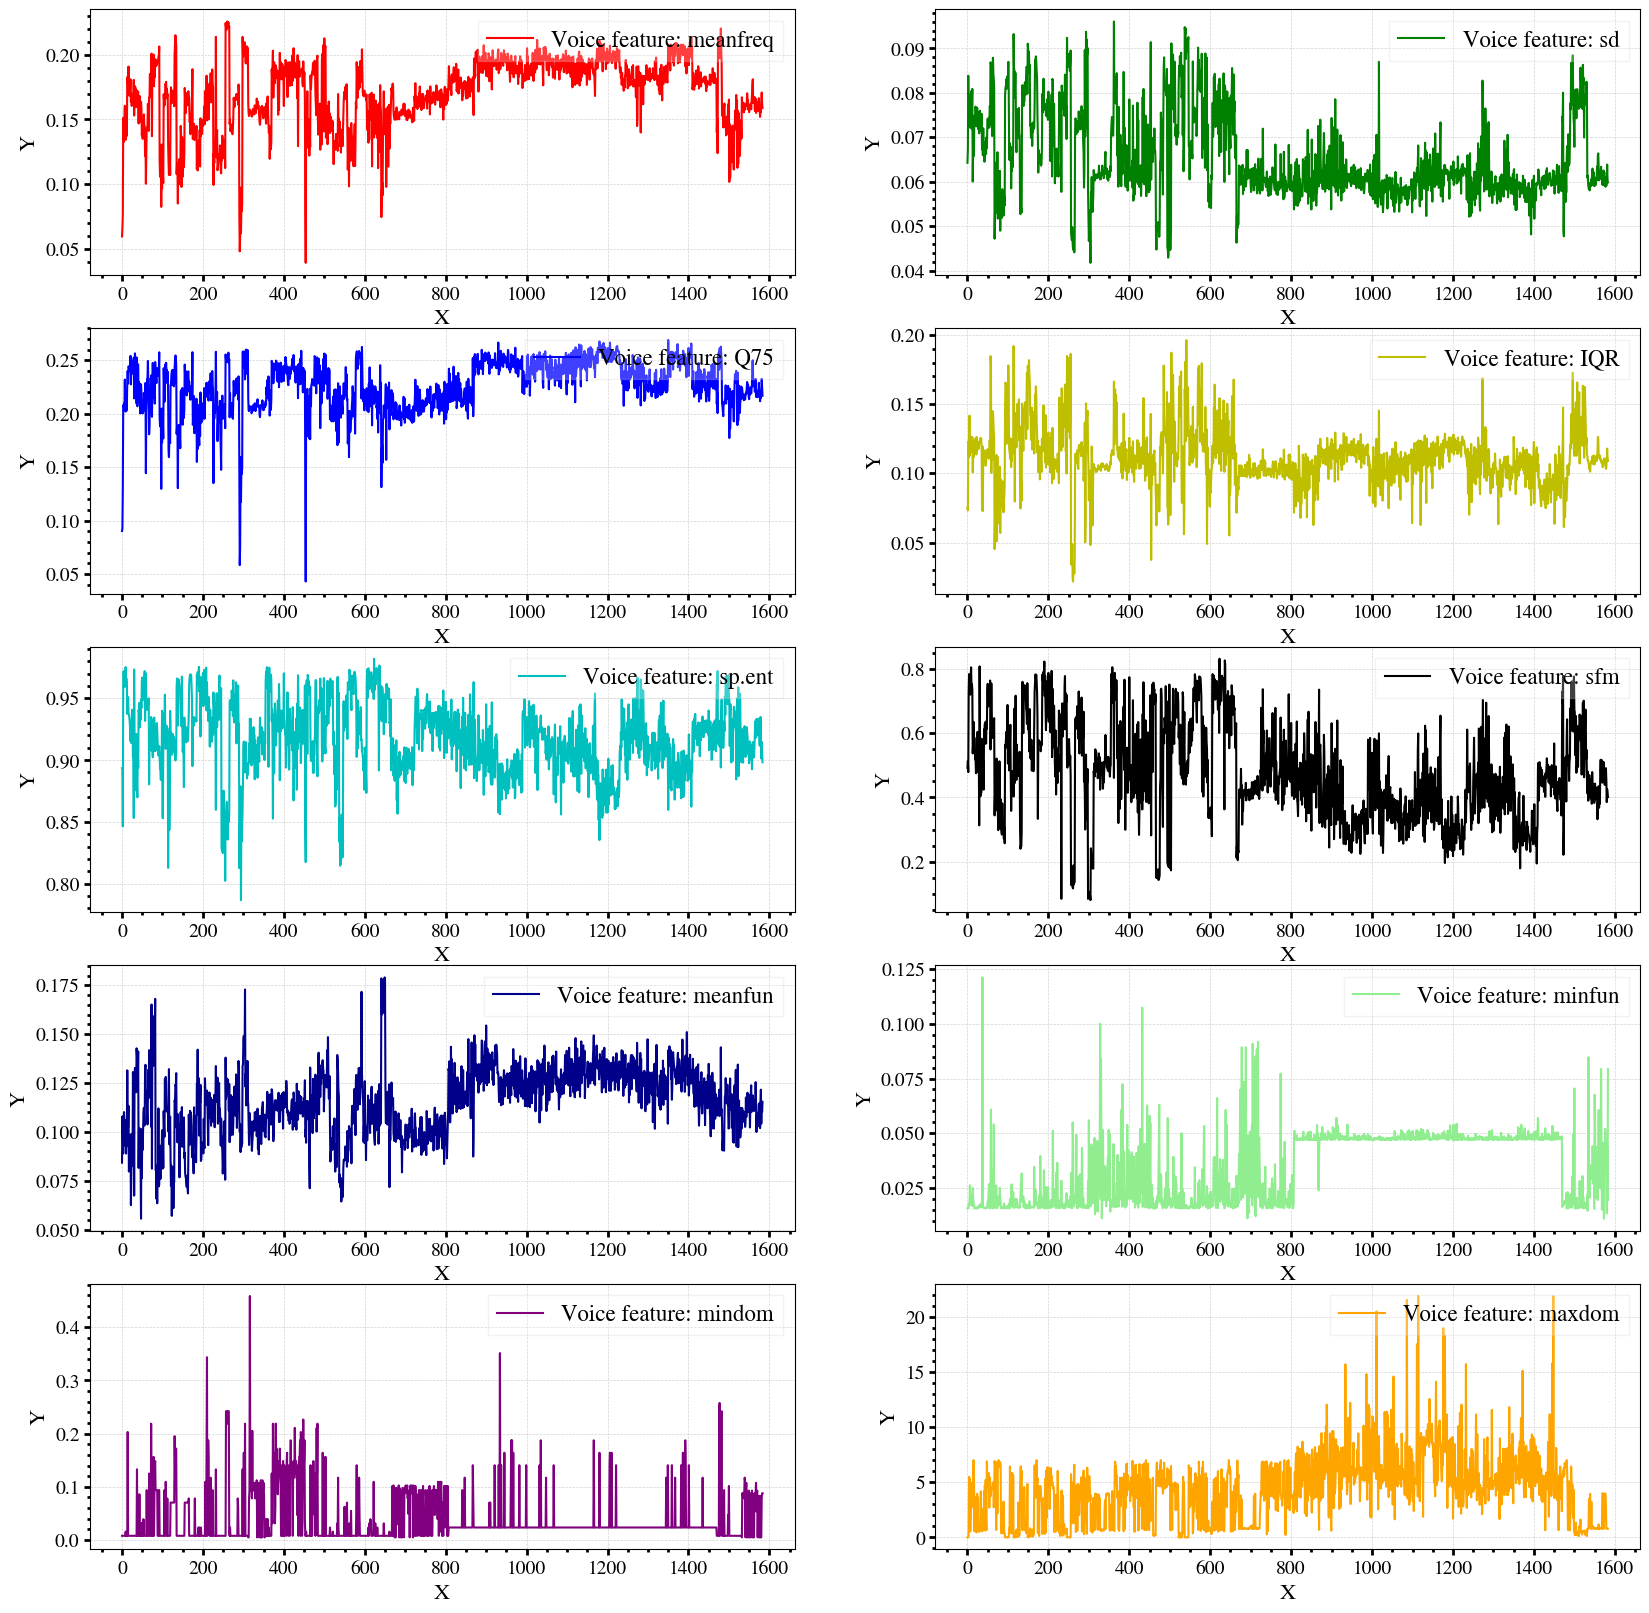

In [ ]:
# Acoustic Parameters of Obesity
obesity_df = df[df['label'] == 'Yes']
obesity_df = obesity_df.drop(['label'], axis=1)
features = obesity_df.keys()
plot_features(obesity_df, features)

# Plot some acoustic features WITHOUT Obesity

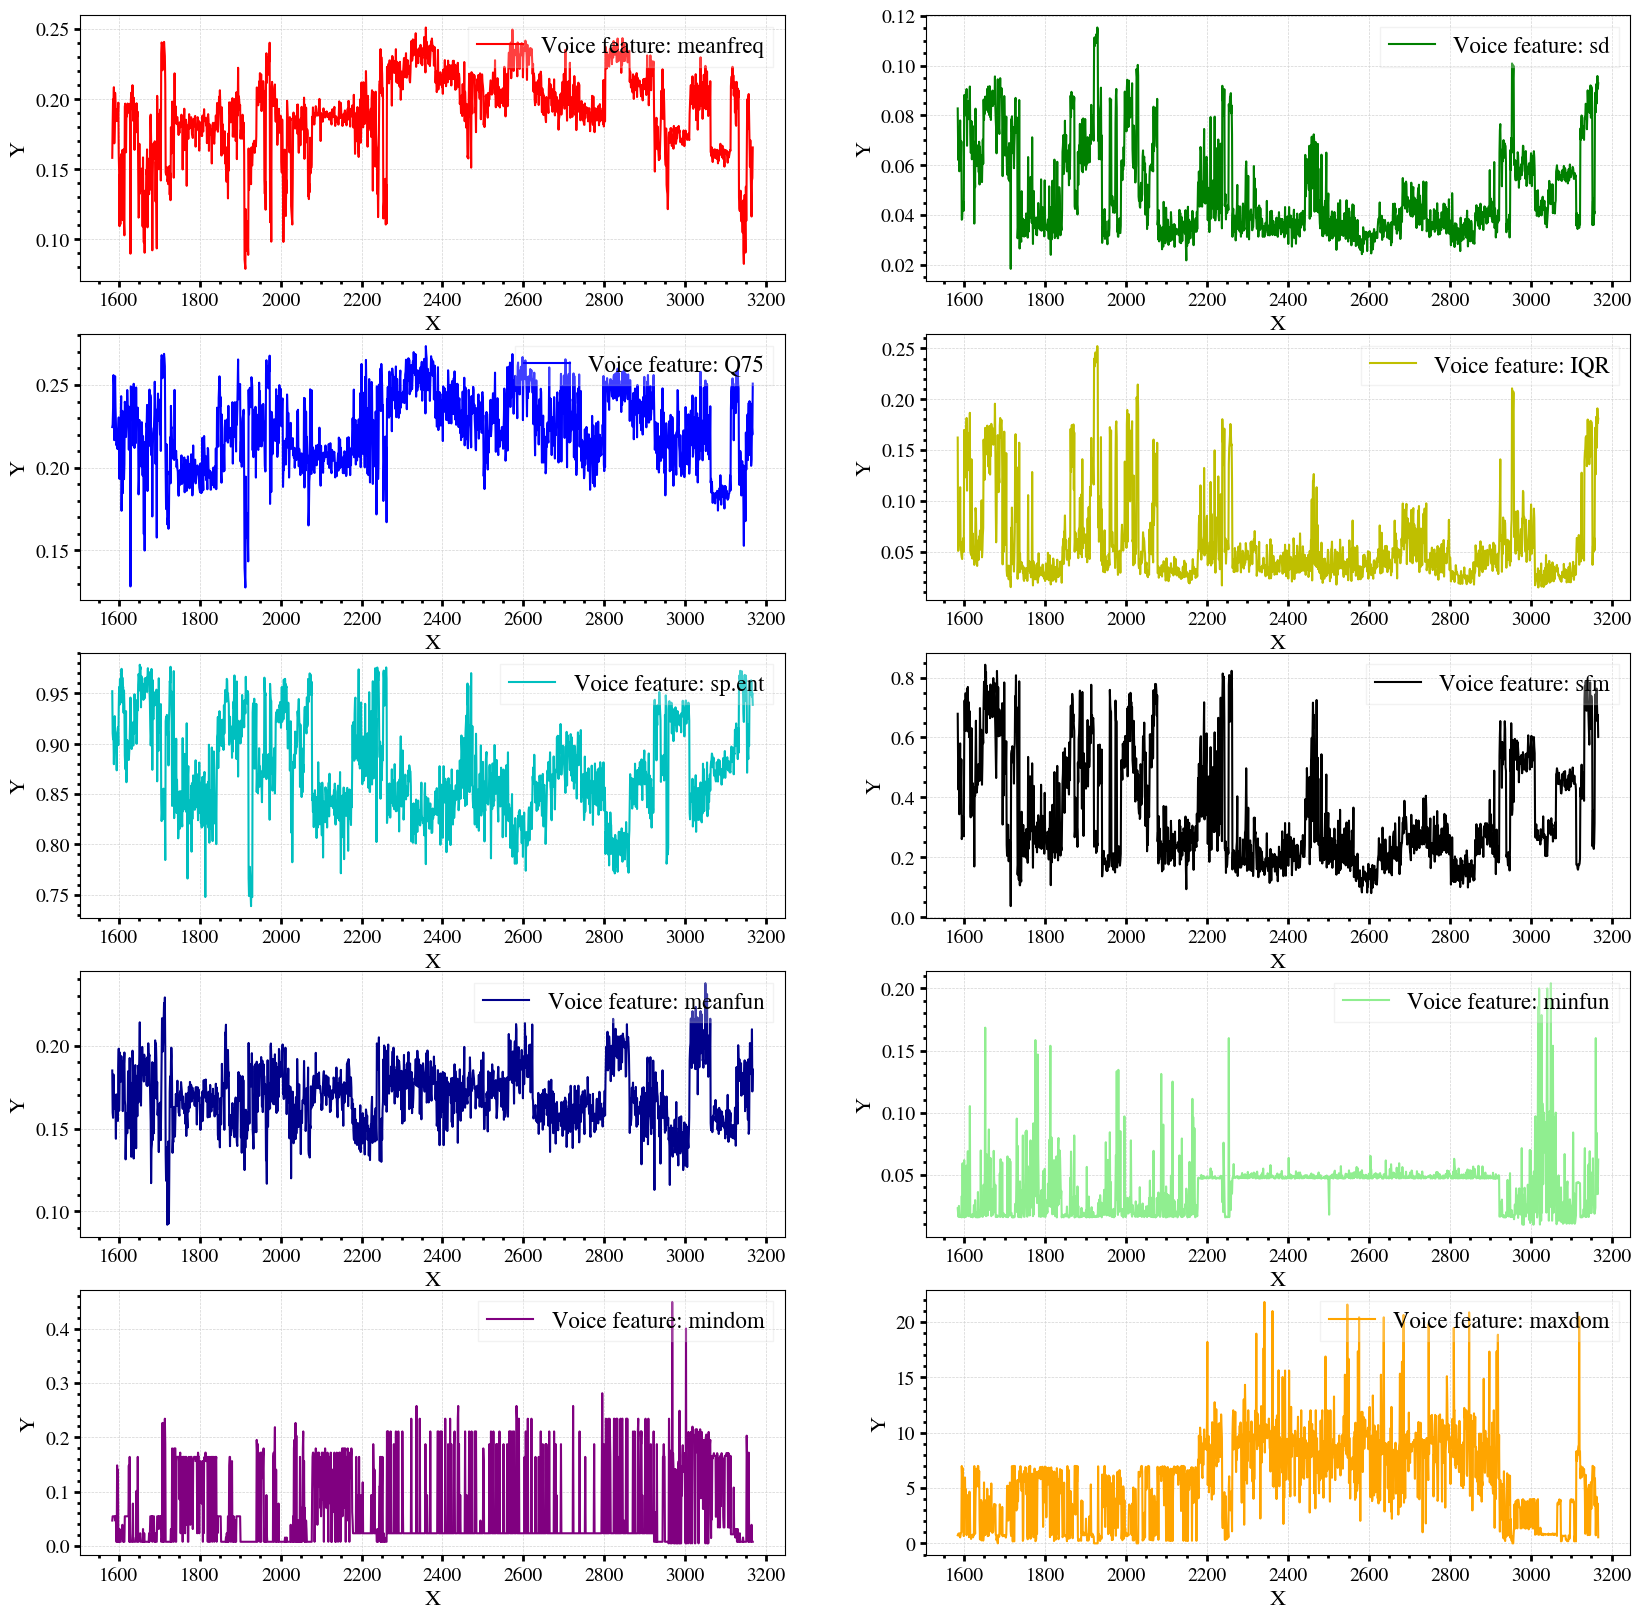

In [ ]:
# Acoustic Parameters without Obesity
no_obesity_df = df[df['label'] == 'No']
no_obesity_df = no_obesity_df.drop(['label'], axis=1)
features_false = no_obesity_df.keys()
plot_features(no_obesity_df, features_false)

# Creating Train and Target (or Label) data from data

In [ ]:
# dropping label, we get our Train data
X = df.drop(['label'], axis=1)

# taking only label as target
Y = df['label']

# Preprocessing Data before prediction

In [ ]:
# Using LabelEncoder to Encode our label {'Yes':1, 'No':0}
Label_Encoder = LabelEncoder()

# Fitting Y data in Label_Encoder for Encoding
Label_Encoder.fit(Y)

# Transforming Data to {'male':1, 'female':0}
Y_Encoded = Label_Encoder.transform(Y)
Y_Encoded

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
# Using StandardScaler to scale Train Data
Standard_Scaler = StandardScaler()

# fitting X data in Standard_Scaler
Standard_Scaler.fit(X)

# Transforming to scale data
X_Scaled = Standard_Scaler.transform(X)

# priting scaled data
X_Scaled

array([[-4.04924806,  0.4273553 , -4.22490077, ..., -1.43142165,
        -1.41913712, -1.45477229],
       [-3.84105325,  0.6116695 , -3.99929342, ..., -1.41810716,
        -1.4058184 , -1.01410294],
       [-3.46306647,  1.60384791, -4.09585052, ..., -1.42920257,
        -1.41691733, -1.06534356],
       ...,
       [-1.29877326,  2.32272355, -0.05197279, ..., -0.5992661 ,
        -0.58671739,  0.17588664],
       [-1.2452018 ,  2.012196  , -0.01772849, ..., -0.41286326,
        -0.40025537,  1.14916112],
       [-0.51474626,  2.14765111, -0.07087873, ..., -1.27608595,
        -1.2637521 ,  1.47567886]])

In [ ]:
# splitting Data into training and testing Data using cross_validation.train_test_split
# Train - Test data ratio of 75%-25%
# Random State to Randomize data = 42
X_train, X_test, Y_train, Y_test = train_test_split(X_Scaled,Y_Encoded,test_size = 0.25, random_state=42)

# Build and compile a Neural Network model

In [ ]:
# Build the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Dropout for regularization
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Train the Neural Network

In [ ]:
# Train the Neural Network
history = model.fit(X_train, Y_train, epochs=50, batch_size=32, validation_data=(X_test, Y_test))

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7151 - loss: 0.5358 - val_accuracy: 0.9659 - val_loss: 0.1377
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9499 - loss: 0.1485 - val_accuracy: 0.9760 - val_loss: 0.0824
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9764 - loss: 0.0883 - val_accuracy: 0.9785 - val_loss: 0.0719
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9690 - loss: 0.0927 - val_accuracy: 0.9811 - val_loss: 0.0705
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9800 - loss: 0.0699 - val_accuracy: 0.9760 - val_loss: 0.0696
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9733 - loss: 0.0781 - val_accuracy: 0.9785 - val_loss: 0.0659
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9837 - loss: 0.0635 - val_accuracy: 0.9823 - val_loss: 0.0640
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9823 - loss: 0.0598 - val_accuracy: 0.9823 - val_l

# Data and Output Visualizations

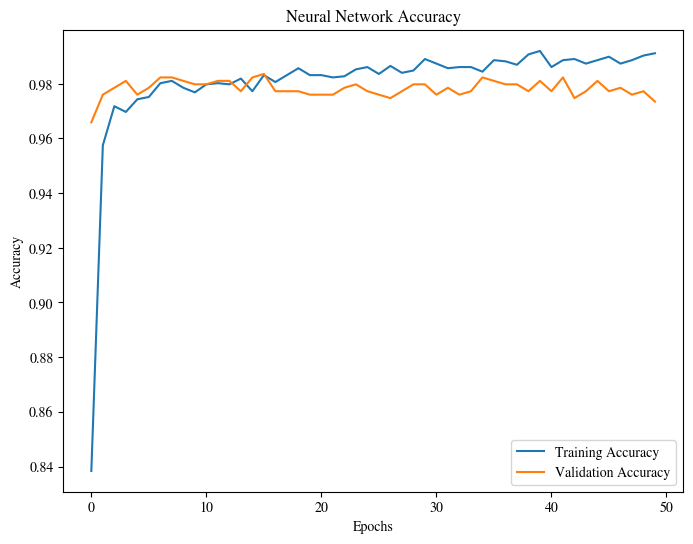

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Accuracy')
plt.show()

In [ ]:
# Good! After training for 50 epochs, the Neural Network yields an accuracy of 98%.

# Confusion Matrix for the results from the Neural Network

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


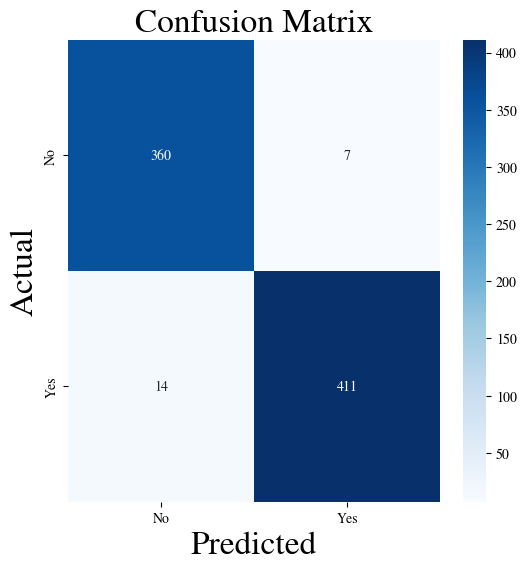

In [ ]:
# Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype("int32")
conf_matrix = confusion_matrix(Y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=Label_Encoder.classes_, yticklabels=Label_Encoder.classes_)
plt.xlabel('Predicted', fontsize=24)
plt.ylabel('Actual', fontsize=24)
plt.title('Confusion Matrix', fontsize=24)
plt.show()

# Classification report for the Neural Network

In [ ]:
# Print classification report
print('Here')
print('Here: "Yes" means "Obesity"')
print('Here: "No" means "Without Obesity"')
print()
print(classification_report(Y_test, y_pred, target_names=Label_Encoder.classes_))

Here
Here: "Yes" means "Obesity"
Here: "No" means "Without Obesity"

              precision    recall  f1-score   support

          No       0.96      0.98      0.97       367
         Yes       0.98      0.97      0.98       425

    accuracy                           0.97       792
   macro avg       0.97      0.97      0.97       792
weighted avg       0.97      0.97      0.97       792



# Below, I will add one more Machine Learning method. I use "Vector Machine" Algorithm here.

# Other Machine Learning models: Vector Machine Algorithm here

In [ ]:
# Support Vector Machine Algorithm for Prediction
# creating Classifier
clf = svm.SVC(C = 200, gamma = 0.1)

# Training Machine Learning Vector Machine model

In [ ]:
# Training our Classifier
clf.fit(X_train,Y_train)

SVC(C=200, gamma=0.1)

# Prediction using Vector Machine model

In [ ]:
# predicting our test data
prediction = clf.predict(X_test)
prediction

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,

# Calculating Accuracy of prediction of Our model

In [ ]:
accuracy = accuracy_score(prediction,Y_test)
accuracy

0.9810606060606061

In [ ]:
# Good: Around 98% accuracy here

# Cross-Validation on different Kernels

In [ ]:
# Defining three different kernels
kernels = ['linear','rbf','poly']

score = []

for i in kernels:
    clf = svm.SVC(kernel = i)
    accuracy = cross_val_score(clf,X_Scaled,Y_Encoded,cv = 15, scoring='accuracy')
    score.append(accuracy.mean())
for i in range(len(kernels)):
    print(kernels[i],':',score[i])

linear : 0.9684610569614592
rbf : 0.9649870338907269
poly : 0.9463516051149067


In [ ]:
# Good: Other kernels also give high accuracies.